In [39]:
if(!require(readr)) install.packages("readr")
library(readr)

github= paste0("https://raw.githubusercontent.com/agronomy4future/",
                "raw_data_practice/refs/heads/main/",
                "fertilizer_treatment.csv")
df= data.frame(read_csv(url(github),show_col_types = FALSE))

In [40]:
set.seed(100)
print(df[sample(nrow(df),5),])

     Genotype Block    variable value
10 Genotype_C    II     Control  58.5
55 Genotype_B   III Fertilizer3  44.1
38 Genotype_B    II Fertilizer2  65.8
48 Genotype_D    IV Fertilizer2  51.0
51 Genotype_A   III Fertilizer3  28.3


In [41]:
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)
df1= df %>%
       group_by(Genotype, variable) %>%
       dplyr::summarize(
       across(
        .cols= value,
        .fns= list(
         Mean= ~mean(., na.rm= TRUE),
         n= ~length(.),
         se= ~sd(., na.rm= TRUE) / sqrt(length(.)))),
        .groups= "drop") %>%
        as.data.frame()

In [72]:
set.seed(100)
print(df1[sample(nrow(df1),5),])

     Genotype    variable value_Mean value_n value_se
10 Genotype_C Fertilizer1     51.375       4 4.163807
7  Genotype_B Fertilizer2     53.100       4 5.790509
6  Genotype_B Fertilizer1     55.375       4 5.684244
3  Genotype_A Fertilizer2     45.850       4 3.471911
9  Genotype_C     Control     53.925       4 3.991319


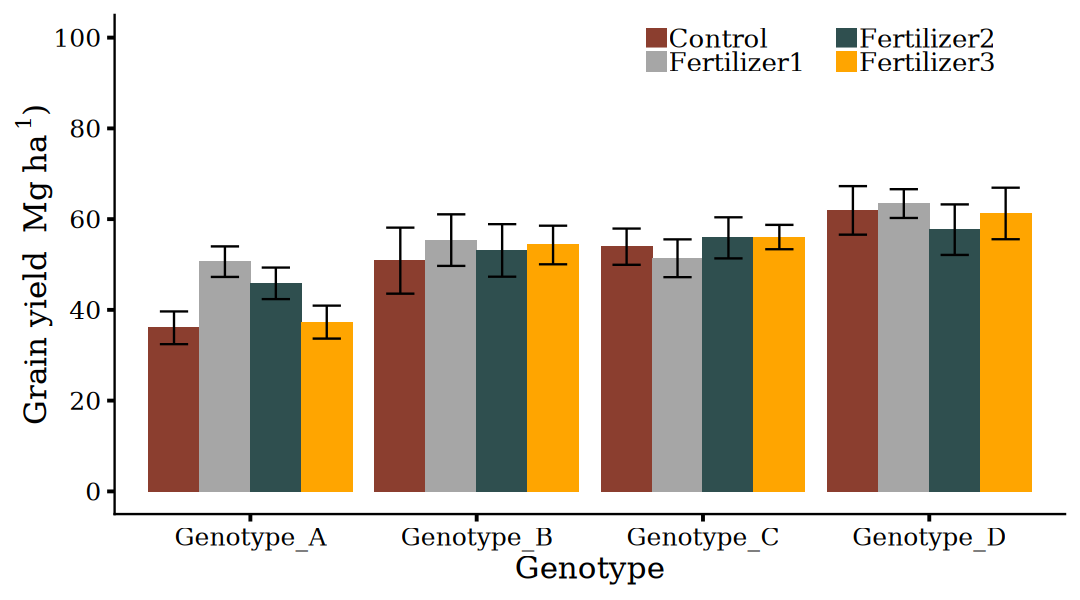

In [73]:
Fig1= ggplot(data=df1, aes(x=Genotype, y=value_Mean, fill=variable))+
  geom_bar(stat="identity",position="dodge", width=0.9) +
  geom_errorbar(aes(ymin=value_Mean-value_se, ymax=value_Mean+value_se), 
  position=position_dodge(0.9), width=0.5, linewidth=0.5) +
  scale_fill_manual(values=c("coral4","grey65","darkslategrey","orange"))+
  scale_y_continuous(breaks=seq(0,100,20), limits = c(0,100)) +
  labs(x="Genotype", y=bquote("Grain yield "~Mg~ha^-1*")")) +

  guides(fill = guide_legend(nrow=2, keywidth=1)) +

  theme_classic(base_size=18, base_family="serif")+
  theme(legend.position=c(0.75,0.93),
        legend.title=element_blank(),
        legend.key=element_rect(color="white", fill="white"),
        legend.key.size=unit(0.5,'cm'),
        legend.text=element_text(family="serif", face="plain",
        size=15, color="black", margin=margin(r=1, unit='cm')),
        legend.background=element_rect(fill="white"),
        axis.line=element_line(linewidth=0.5, colour="black"),
        strip.background=element_rect(color="white", 
        linewidth=0.5,linetype="solid"))

options(repr.plot.width=9, repr.plot.height=5)
print(Fig1)
ggsave("Fig1.png", plot= Fig1, width=9, height= 5, dpi= 300)